In [1]:
import numpy as np
import matplotlib.pyplot as plt
import proplot as plot
import pandas as pd
import os
import xarray as xr


/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian-py310/lib/python3.10/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:

def pred_TEX_from_t_sf2_tc(tex):
       return 0.012*tex + 0.33

In [3]:
# set the path to local folder other than github
login_name = os.getlogin()
### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'

In [4]:
fpath = fr'{local_github_path}/nc_files'
fname = 'ds06_calculated_ocean_properties.nc'

ds = xr.open_dataset(f'{fpath}/{fname}')
ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

In [5]:
fpath2 = fr'{local_documents_path}/Postdoc/TEXAS-PSM/netcdf/WOA-database/WOA23/WOA-decav'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [6]:
### NEMO nitrate data
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/netcdf/Copernicus Marine Service/processed-files/Global-Biogeochemistry/climo-monthly/no3'
fname = r'mercatorfreebiorys2v4_global_mean_ANN_199301_202212_climo.nc'

nitrate_CMEMS_ds = xr.open_dataset(os.path.join(fpath,fname))
nitrate_CMEMS_ds = nitrate_CMEMS_ds.isel(time=0).drop('time')
nitrate_CMEMS_ds = nitrate_CMEMS_ds.rename({'latitude':'lat','longitude':'lon'})
nitrate_CMEMS_da = nitrate_CMEMS_ds.no3.load() ### convert mmol/L to umol/L to make it comparable to WOA data
nitrate_CMEMS_da

depth_coord = nitrate_CMEMS_da.depth
depth_coord = depth_coord - depth_coord[0]
nitrate_CMEMS_da = nitrate_CMEMS_da.assign_coords(depth=depth_coord)
nitrate_CMEMS_da

<xarray.DataArray 'no3' (depth: 75, lat: 681, lon: 1440)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [5.7781367, 5.779535 , 5.7808266, ..., 5.7733583, 5.775043 ,
         5.7766376],
        [5.720044 , 5.7206492, 5.721291 , ..., 5.718462 , 5.7189493,
         5.719477 ],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
  * lat      (lat) float32 -80.0 -79.75 -79.5 -79.25 ... 89.25 89.5 89.75 90.0
  * depth    (depth) float32 0.0 1.05 2.162 ... 5.494e+03 5.698e+03 5.902e+03
Attributes:
    long_name:      Nitrate
    standard_name:  mole_concentration_of_nitrate_in_sea_water
    units:          mmol m-3
    unit_long:      millimoles of Nitrate per cubic meter
    valid_min:      0.0
    valid_max:      59.31268
    cell_methods:   time: mean

In [11]:
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/netcdf/Copernicus Marine Service/processed-files/Global-Biogeochemistry/climo-monthly/no3/'

## gathering montly nc file from the fpath
month_str_list = ['01','02','03','04','05','06','07','08','09','10','11','12']
nitrate_monthly_da_list = [os.path.join(fpath, f'mercatorfreebiorys2v4_global_mean_{month_str}_1993{month_str}_2022{month_str}_climo.nc') for month_str in month_str_list]

monthly_nitrate_ds = xr.open_mfdataset(nitrate_monthly_da_list, combine='by_coords')

## change the time coordinate to month number
monthly_nitrate_ds = monthly_nitrate_ds.rename({'time':'month'})
monthly_nitrate_ds = monthly_nitrate_ds.assign_coords(month=np.arange(1, 13))
monthly_nitrate_ds['log10_no3'] = np.log10(monthly_nitrate_ds.no3)
monthly_nitrate_ds

<xarray.Dataset>
Dimensions:    (longitude: 1440, latitude: 681, depth: 75, month: 12)
Coordinates:
  * longitude  (longitude) float32 -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * latitude   (latitude) float32 -80.0 -79.75 -79.5 -79.25 ... 89.5 89.75 90.0
  * depth      (depth) float32 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
  * month      (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    no3        (month, depth, latitude, longitude) float32 dask.array<chunksize=(1, 75, 681, 1440), meta=np.ndarray>
    log10_no3  (month, depth, latitude, longitude) float32 dask.array<chunksize=(1, 75, 681, 1440), meta=np.ndarray>
Attributes: (12/21)
    product:                       GLOBAL_REANALYSIS_BIO_001_029
    producer:                      CMEMS - Global Monitoring and Forecasting ...
    title:                         Monthly mean fields for product GLOBAL_REA...
    area:                          GLOBAL
    quality_information_document:  http://marine.copernicus.eu/documents/QUID...
    Conventions:                   CF-1.6
    ...                            ...
    climo_script:                  ncclimo
    climo_command:                 '/usr/bin/ncclimo -4 --clm_md=mth -c merca...
    climo_hostname:                paleolipidrr
    climo_version:                 5.0.6
    yrs_averaged:                  1993-2022
    NCO:                           netCDF Operators version 5.0.6 (Homepage =...

In [8]:
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/netcdf/Copernicus Marine Service/processed-files/Global-Biogeochemistry/climo-monthly/chl/'

## gathering montly nc file from the fpath
month_str_list = ['01','02','03','04','05','06','07','08','09','10','11','12']
nitrate_monthly_da_list = [os.path.join(fpath, f'mercatorfreebiorys2v4_global_mean_{month_str}_1993{month_str}_2022{month_str}_climo.nc') for month_str in month_str_list]

monthly_chl_ds = xr.open_mfdataset(nitrate_monthly_da_list, combine='by_coords')

## change the time coordinate to month number
monthly_chl_ds = monthly_chl_ds.rename({'time':'month'})
monthly_chl_ds = monthly_chl_ds.assign_coords(month=np.arange(1, 13))
monthly_chl_ds['log10_chl'] = np.log10(monthly_chl_ds.chl)
monthly_chl_ds

<xarray.Dataset>
Dimensions:    (longitude: 1440, latitude: 681, depth: 75, month: 12)
Coordinates:
  * longitude  (longitude) float32 -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * latitude   (latitude) float32 -80.0 -79.75 -79.5 -79.25 ... 89.5 89.75 90.0
  * depth      (depth) float32 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
  * month      (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    chl        (month, depth, latitude, longitude) float32 dask.array<chunksize=(1, 75, 681, 1440), meta=np.ndarray>
    log10_chl  (month, depth, latitude, longitude) float32 dask.array<chunksize=(1, 75, 681, 1440), meta=np.ndarray>
Attributes: (12/21)
    product:                       GLOBAL_REANALYSIS_BIO_001_029
    producer:                      CMEMS - Global Monitoring and Forecasting ...
    title:                         Monthly mean fields for product GLOBAL_REA...
    area:                          GLOBAL
    quality_information_document:  http://marine.copernicus.eu/documents/QUID...
    Conventions:                   CF-1.6
    ...                            ...
    climo_script:                  ncclimo
    climo_command:                 '/usr/bin/ncclimo -4 --clm_md=mth -c merca...
    climo_hostname:                paleolipidrr
    climo_version:                 5.0.6
    yrs_averaged:                  1993-2022
    NCO:                           netCDF Operators version 5.0.6 (Homepage =...

In [9]:
fpath = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/monthly/'

## gathering montly nc file from the fpath
month_str_list = ['01','02','03','04','05','06','07','08','09','10','11','12']
temperature_monthly_da_list = [os.path.join(fpath, f'woa23_decav91C0_t{month_str}_04.nc') for month_str in month_str_list]

monthly_temp_ds = xr.open_mfdataset(temperature_monthly_da_list, combine='by_coords',decode_times=False)

## change the time coordinate to month number
monthly_temp_ds = monthly_temp_ds.rename({'time':'month'})
monthly_temp_ds = monthly_temp_ds.assign_coords(month=np.arange(1, 13))
monthly_temp_ds

<xarray.Dataset>
Dimensions:             (month: 12, lat: 720, nbounds: 2, lon: 1440, depth: 57)
Coordinates:
  * lat                 (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon                 (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * depth               (depth) float32 0.0 5.0 10.0 ... 1.45e+03 1.5e+03
  * month               (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nbounds
Data variables: (12/15)
    crs                 (month) int32 -2147483647 -2147483647 ... -2147483647
    lat_bnds            (month, lat, nbounds) float32 dask.array<chunksize=(1, 720, 2), meta=np.ndarray>
    lon_bnds            (month, lon, nbounds) float32 dask.array<chunksize=(1, 1440, 2), meta=np.ndarray>
    depth_bnds          (month, depth, nbounds) float32 dask.array<chunksize=(1, 57, 2), meta=np.ndarray>
    climatology_bounds  (month, nbounds) float32 dask.array<chunksize=(1, 2), meta=np.ndarray>
    t_an                (month, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    ...                  ...
    t_se                (month, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_oa                (month, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_ma                (month, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_gp                (month, depth, lat, lon) float64 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_sdo               (month, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_sea               (month, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
Attributes: (12/45)
    Conventions:                     CF-1.6
    title:                           World Ocean Atlas 2023 : sea_water_tempe...
    summary:                         Climatological mean temperature for the ...
    references:                      Locarnini, R.A., A.V. Mishonov, O.K. Bar...
    institution:                     NOAA National Centers for Environmental ...
    comment:                         Global Climatology as part of the World ...
    ...                              ...
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v1.0
    license:                         These data are openly available to the p...
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    metadata_link:                   https://www.ncei.noaa.gov/products/world...
    date_created:                    2024-01-28 
    date_modified:                   2024-01-28

/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian-py310/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian-py310/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian-py310/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian-py310/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: 

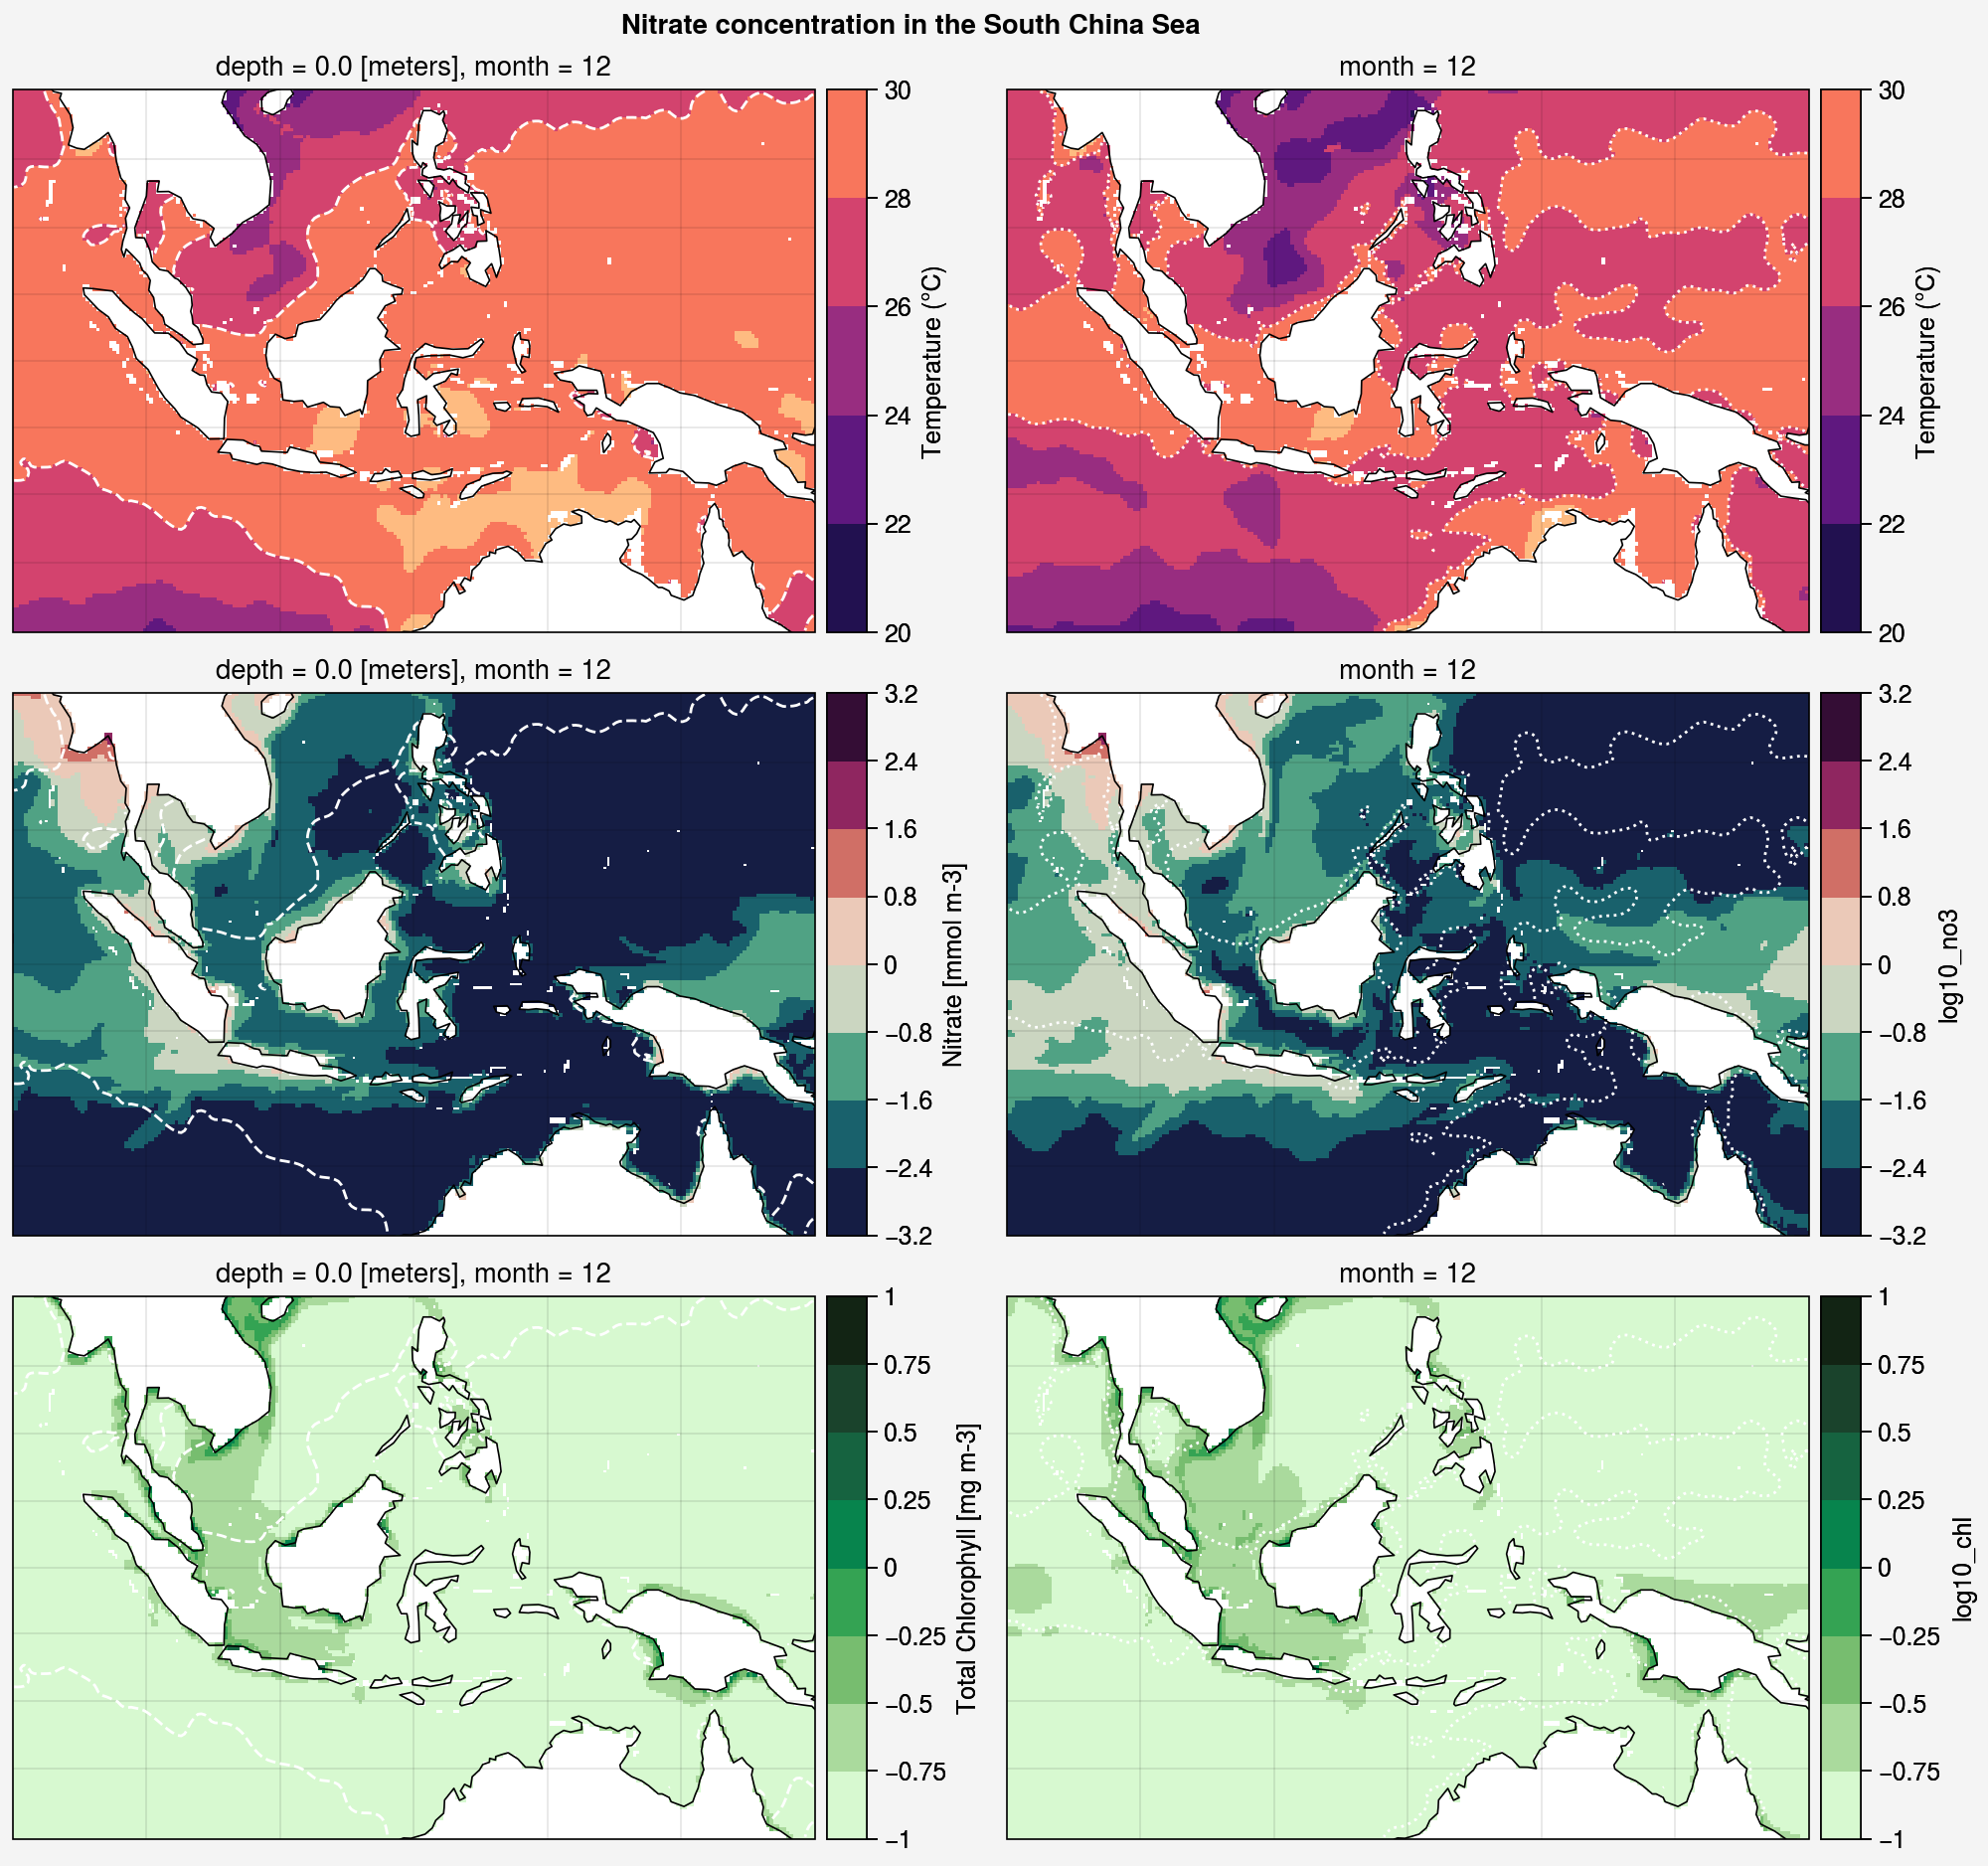

In [12]:
fpath = '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/figures/miscellaneous/'

for sel_month in range(0,12):

    plt.close('all')
    fig, axs = plot.subplots(proj='merc',width=10,ncols=2,nrows=3)
    
    
    subset_temp_data = monthly_temp_ds.isel(month=sel_month).sel(depth=slice(0,100),
                                                    lon=slice(90,150),
                                                    lat=slice(-20,20))
    ax = axs[0]
    subset_temp_data.isel(depth=0).t_an.plot(ax=ax,cmap='Magma',
                                             levels=np.arange(20,31,2),
                                             cbar_kwargs={'label':'Temperature (°C)'})
    ax.set_title(f'Month: {sel_month+1} (Surface)')

    ax = axs[1]
    subset_temp_data.mean('depth').t_an.plot(ax=ax,cmap='Magma',
                                             levels=np.arange(20,31,2),
                                             cbar_kwargs={'label':'Temperature (°C)'})
    ax.set_title(f'Month: {sel_month+1} (Mean 0-100m)')

    subset_data = monthly_nitrate_ds.isel(month=sel_month).sel(depth=slice(0,100),
                                                    longitude=slice(90,150),
                                                    latitude=slice(-20,20))
    ax = axs[2]
    subset_data.isel(depth=0).log10_no3.plot(ax=ax,cmap='Curl')
    ax.set_title(f'Month: {sel_month+1} (Surface)')
    

    ax = axs[3]
    subset_data.mean('depth').log10_no3.plot(ax=ax,cmap='Curl')
    ax.set_title(f'Month: {sel_month+1} (Mean 0-100m)')
    
    subset_chl_data = monthly_chl_ds.isel(month=sel_month).sel(depth=slice(0,100),
                                                    longitude=slice(90,150),
                                                    latitude=slice(-20,20))
    ax = axs[4]
    subset_chl_data.isel(depth=0).log10_chl.plot(ax=ax,cmap='Algae')
    ax.set_title(f'Month: {sel_month+1} (Surface)')
    
    ax = axs[5]
    subset_chl_data.mean('depth').log10_chl.plot(ax=ax,cmap='Algae')
    ax.set_title(f'Month: {sel_month+1} (Mean 0-100m)')
    
    ## add 28 degC isotherm to all surface plots (left column)
    T_isotherm = 28
    subset_temp_data.isel(depth=0).t_an.plot.contour(ax=axs[:,0], levels=[0,T_isotherm], colors='white',
                                                     lw=1,ls='--')
    
    ## add 28 degC isotherm to all mean 0-100m plots (right column)
    subset_temp_data.mean('depth').t_an.plot.contour(ax=axs[:,1], levels=[0,T_isotherm], colors='white',
                                                     lw=1,ls=':')
    
    axs.format(latlim=(-20,20),lonlim=(90,150),
            suptitle='Nitrate concentration in the South China Sea',
            xlabel='Longitude', ylabel='Latitude',
            coast=True,)

    fig.savefig(fpath+f'monthly_nitrate_{sel_month+1:02d}.png', dpi=300, bbox_inches='tight')
    
#     break


In [13]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'

def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(66.6667,-18.6667),
        'schouteN_meso003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(0.015,0.280),
        'schouteN_meso003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

In [14]:
fpath = fr'{local_github_path}/spreadsheets/fitted_models'
fname = 'ols_tex_thermoT_thisStudy.pkl'

import pickle

with open(os.path.join(fpath,fname), 'rb') as f:
    ols_tex_thermoT = pickle.load(f)
    
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_

fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = 'PhanSST_v001.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanSST_df['pubYear'] = PhanSST_df['LeadAuthor'] + PhanSST_df['Year'].astype(str)

PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
                                        'GDGT0':'fGDGT_0',
                                        'GDGT1':'fGDGT_1',
                                        'GDGT2':'fGDGT_2',
                                        'GDGT3':'fGDGT_3',
                                        'Cren':'fGDGT_cren',
                                        'Crenisomer':'fGDGT_cren_prime'})
PhanTEX_df = PhanTEX_df.dropna(subset=['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']).reset_index(drop=True)


features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
PhanTEX_df['ringIndex'] = np.array([PhanTEX_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']

PhanTEX_df['thermoT_linear'] = (PhanTEX_df['TEX86'] - intercept)/slope
PhanTEX_df['SST_Schouten02'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='schouteN_meso002')
PhanTEX_df['SST_Kim10'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='kim2010_tex86H')
PhanTEX_df

/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian-py310/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tmp/ipykernel_187218/3855987089.py:14: DtypeWarning: Columns (0,6,7,14,15,22,23,24,25,26,27,54) have mixed types. Specify dtype option on import or set low_memory=False.
  PhanSST_df = pd.read_csv(os.path.join(fpath,fname))


,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,Year,PublicationDOI,DataDOI,pubYear,ringIndex,scaledRI,gdgt23ratio,thermoT_linear,SST_Schouten02,SST_Kim10
0,NaN,Aderet 1,NaN,NaN,NaN,265.30,NaN,Israel,as,31.65,...,2013,https://doi.org/10.1016/j.palaeo.2013.09.013,NaN,Alsenz2013,2.692752,0.673188,2.975410,30.333373,28.061152,28.043613
1,NaN,Aderet 1,NaN,NaN,NaN,268.20,NaN,Israel,as,31.65,...,2013,https://doi.org/10.1016/j.palaeo.2013.09.013,NaN,Alsenz2013,2.676383,0.669096,2.711864,32.086507,29.491964,28.939558
2,NaN,Aderet 1,NaN,NaN,NaN,271.60,NaN,Israel,as,31.65,...,2013,https://doi.org/10.1016/j.palaeo.2013.09.013,NaN,Alsenz2013,2.792211,0.698053,2.599119,30.764599,28.413095,28.266512
3,NaN,Aderet 1,NaN,NaN,NaN,274.59,NaN,Israel,as,31.65,...,2013,https://doi.org/10.1016/j.palaeo.2013.09.013,NaN,Alsenz2013,2.877008,0.719252,3.118881,31.479751,28.996763,28.632522
4,NaN,Aderet 1,NaN,NaN,NaN,277.55,NaN,Israel,as,31.65,...,2013,https://doi.org/10.1016/j.palaeo.2013.09.013,NaN,Alsenz2013,2.626159,0.656540,3.213920,30.576403,28.259500,28.169440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7849,NaN,Mid-Waipara River,NaN,NaN,NaN,173.75,NaN,New Zealand,au,-43.06,...,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN,Hollis2012,3.127375,0.781844,2.472160,36.970684,33.478162,31.301895
7850,NaN,Mid-Waipara River,NaN,NaN,NaN,170.40,NaN,New Zealand,au,-43.06,...,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN,Hollis2012,3.028662,0.757166,2.614379,34.248892,31.256785,30.008682
7851,NaN,Mid-Waipara River,NaN,NaN,NaN,167.04,NaN,New Zealand,au,-43.06,...,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN,Hollis2012,3.270462,0.817615,2.232558,38.763949,34.941727,32.124169
7852,NaN,Mid-Waipara River,NaN,NaN,NaN,164.81,NaN,New Zealand,au,-43.06,...,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN,Hollis2012,3.198866,0.799717,2.287009,38.929990,35.077240,32.199165


In [15]:
PhanTEX_df[PhanTEX_df['Age']<2.58].SiteName.unique()

array(['B997-316', 'DSDP231', 'DSDP610', 'IODPU1459', 'IODPU1460',
       'IODPU1463', 'LV53-19-1', 'MD97-2151', 'MD98-2152', 'ODP1087',
       'ODP1146', 'ODP1229', 'ODP1239', 'ODP608', 'ODP806', 'ODP850',
       'ODP882', 'ODP925', 'ODP959', 'ODP964', 'ODP967', 'ODP969',
       'ODP982', 'P178-15P', 'SO201-2-114KL', 'SO201-2-12KL'],
      dtype=object)

/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian-py310/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/tmp/ipykernel_187218/2784341486.py:2: ProplotWarning: Ignoring unused projection-specific format() keyword argument(s): {'xlabel': 'Longitude', 'ylabel': 'Latitude'}
  axs.format(latlim=(-20,20),lonlim=(90,150),


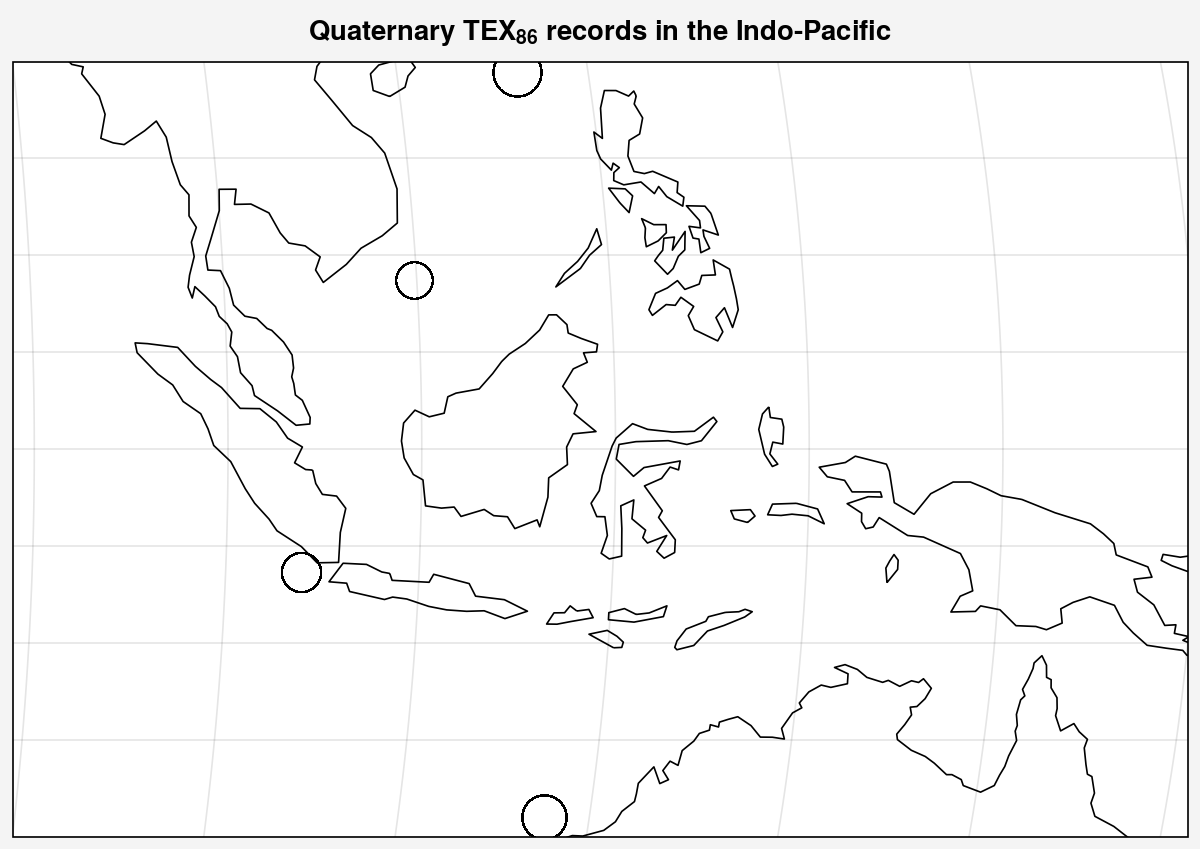

In [28]:
fig, axs = plot.subplots(proj='eck3',width=6)
axs.format(latlim=(-20,20),lonlim=(90,150),
            suptitle='Quaternary TEX$_{86}$ records in the Indo-Pacific',
            xlabel='Longitude', ylabel='Latitude',
            coast=True)
### plot Quaternary data on the map
plot_data = PhanTEX_df[PhanTEX_df['Age']<2.58].copy()

grouped_data = plot_data.groupby('SiteName')
for site_name, group in grouped_data:
    ax = axs[0]
    ax.scatter(group['ModLon'], group['ModLat'], 
                     s=len(group['TEX86']),
                     facecolor='none', 
                     mec='k',
                     linewidth=0.5, 
                     label=site_name)

/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian-py310/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/tmp/ipykernel_10631/3630253373.py:6: ProplotWarning: Ignoring unused projection-specific format() keyword argument(s): {'xlabel': 'Longitude', 'ylabel': 'Latitude'}
  axs.format(latlim=(-20,20), lonlim=(90,150),
/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian-py310/lib/python3.10/site-packages/xarray/core/computation.py:761: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


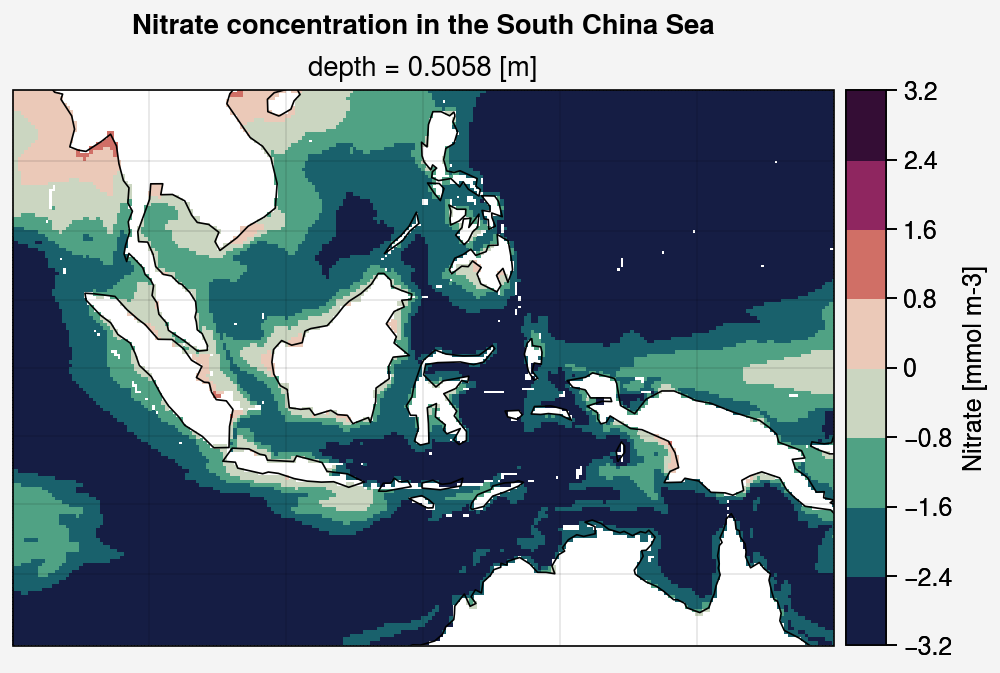

In [83]:
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/netcdf/Copernicus Marine Service/processed-files/Global-Biogeochemistry/climo-monthly/no3/'
month_str = '06'
fname = f'mercatorfreebiorys2v4_global_mean_{month_str}_1993{month_str}_2022{month_str}_climo.nc'

fig, axs = plot.subplots(proj='merc', width=5, ncols=1, nrows=1)
axs.format(latlim=(-20,20), lonlim=(90,150),
            suptitle='Nitrate concentration in the South China Sea',
            xlabel='Longitude', ylabel='Latitude',
            coast=True,)
test_da = xr.open_dataset(os.path.join(fpath,fname)).isel(time=0).drop('time')
test_da['log10_no3'] = np.log10(test_da.no3)
test_da['log10_no3'].isel(depth=0).plot(cmap='Curl')

In [ ]:
CMEMS_no3_100m_avg = nitrate_CMEMS_da.sel(depth=slice(0,100)).mean(dim='depth')
CMEMS_no3_100m_avg

<xarray.DataArray 'no3' (lat: 681, lon: 1440)>
array([[      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [6.2664714, 6.267922 , 6.269262 , ..., 6.2615128, 6.263262 ,
        6.264915 ],
       [6.192842 , 6.1934133, 6.1940236, ..., 6.191383 , 6.1918244,
        6.1923127],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan]], dtype=float32)
Coordinates:
  * lon      (lon) float32 -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
  * lat      (lat) float32 -80.0 -79.75 -79.5 -79.25 ... 89.25 89.5 89.75 90.0

In [ ]:
fpath = fr'/home/ronnie/Documents/GitHub/culRI-Bayesian/spreadsheets'
fname = 'reg_data_revised_122024.csv'

coretop_df = pd.read_csv(f'{fpath}/{fname}', delimiter=',', header=0)
coretop_df

,sampleID,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,fGDGT_0,...,residual_TEX86_kim10H,depth_bin,TEX_residual_OLS,TEX_residual_log10TEX,TEX_residual_OLS_exclude_RS,TEX_residual_log10TEX_exclude_RS,TEX_residual_OLS_thermoT_integral,TEX_residual_log10TEX_thermoT_integral,TEX_residual_OLS_exclude_RS_thermoT_integral,TEX_residual_log10TEX_exclude_RS_thermoT_integral
0,TEXAS_PSM_RR00002,KNR195-5 MC11,MC,6.0,8.0,-1.5327,-86.7852,2288.0,0.602873,0.330589,...,-0.000488,"(2000, 3000]",-0.003968,0.004421,0.000231,0.007747,0.012897,0.023712,0.016545,0.026355
1,TEXAS_PSM_RR00005,KNR195-5 MC18,MC,4.0,6.0,-3.9690,-81.3100,1024.0,0.599447,0.282415,...,0.029586,"(1000, 2000]",0.013049,0.024335,0.016731,0.027141,0.007403,0.017950,0.011109,0.020646
2,TEXAS_PSM_RR00007,KNR195-5 MC25,MC,5.0,7.0,-3.5830,-81.1650,381.0,0.617192,0.292011,...,0.027219,"(0, 1000]",0.018381,0.028019,0.022377,0.031137,0.027611,0.038477,0.031248,0.041110
3,TEXAS_PSM_RR00008,KNR195-5 MC33,MC,3.0,5.0,-3.2237,-82.9142,2949.0,0.605147,0.309270,...,0.038849,"(2000, 3000]",0.020994,0.032542,0.024620,0.035293,0.032989,0.045734,0.036133,0.047936
4,TEXAS_PSM_RR00009,KNR195-5 MC34,MC,4.0,6.0,-3.5975,-83.9632,3224.0,0.588670,0.344233,...,0.009721,"(3000, 4000]",-0.003390,0.007186,0.000436,0.010133,0.012130,0.024464,0.015398,0.026772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760,TEXAS_PSM_RR02077,SY201710_LD-18,NaN,NaN,NaN,20.5700,113.8000,89.0,0.595556,0.236000,...,-0.054672,"(0, 1000]",-0.038058,-0.034899,-0.033182,-0.030835,-0.054613,-0.055616,-0.049261,-0.051265
1761,TEXAS_PSM_RR02078,DO201207-08_QD11a,NaN,NaN,NaN,20.7000,113.3700,81.0,0.512500,0.281000,...,-0.135656,"(0, 1000]",-0.119972,-0.116555,-0.115124,-0.112524,-0.140778,-0.142625,-0.135338,-0.138176
1762,TEXAS_PSM_RR02079,DO201207-08_QD41,NaN,NaN,NaN,20.1400,112.0600,87.0,0.585859,0.236000,...,-0.068119,"(0, 1000]",-0.049813,-0.047126,-0.044885,-0.043002,-0.071414,-0.074382,-0.065861,-0.069805
1763,TEXAS_PSM_RR02080,DO201207-08_E503,NaN,NaN,NaN,19.2000,112.2900,189.0,0.651376,0.237000,...,-0.017503,"(0, 1000]",0.007641,0.008382,0.012773,0.012742,0.009346,0.010442,0.014468,0.014541


In [ ]:
coretop_df['t_sf2tc_avg'] = [ds['t_sf2tc_avg'].sel(lat=lat, lon=lon, method='nearest').values for lat, lon in zip(coretop_df['Latitude'], coretop_df['Longitude'])]
coretop_df['pred_tex'] = pred_TEX_from_t_sf2_tc(coretop_df['t_sf2tc_avg'])
coretop_df['tex_residual'] = coretop_df['TEX86'] - coretop_df['pred_tex']
coretop_df['no3_sf2tc_avg'] = [ds['no3_sf2tc_avg'].sel(lat=lat, lon=lon, method='nearest').values for lat, lon in zip(coretop_df['Latitude'], coretop_df['Longitude'])]
coretop_df['no3_100m_avg'] = [CMEMS_no3_100m_avg.sel(lat=lat, lon=lon, method='nearest').values for lat, lon in zip(coretop_df['Latitude'], coretop_df['Longitude'])]

In [ ]:
fname = 'SonneCoretopTexUk.xlsx'
fpath = fr'/home/ronnie/Documents/GitHub/culRI-Bayesian/spreadsheets'
trang_coretop_df = pd.read_excel(os.path.join(fpath,fname), sheet_name='Tex86_0-2cm',skiprows=2)
features = ['Sample label', 'WaterDepth', 'Latitude', 'Longitude', 'Sample depth',
       'ASE#', 'TEX86','BIT','MI',"RI-sample","Annual SST"]
## drop the first row
trang_coretop_df = trang_coretop_df[features].drop(0)
trang_coretop_df = trang_coretop_df.iloc[:37,:].reset_index(drop=True)

trang_coretop_df['t_sf2tc_avg'] =  [ds['t_sf2tc_avg'].sel(lat=trang_coretop_df['Latitude'][i], 
                                                            lon=trang_coretop_df['Longitude'][i], 
                                                            method='nearest').values for i in range(len(trang_coretop_df))]
trang_coretop_df['pred_tex'] = pred_TEX_from_t_sf2_tc(trang_coretop_df['t_sf2tc_avg'])
trang_coretop_df['tex_residual'] =  trang_coretop_df['TEX86'] - trang_coretop_df['pred_tex']
trang_coretop_df['no3_sf2tc_avg'] = [ds['no3_sf2tc_avg'].sel(lat=trang_coretop_df['Latitude'][i],
                                                                lon=trang_coretop_df['Longitude'][i], 
                                                                method='nearest').values for i in range(len(trang_coretop_df))]
trang_coretop_df['no3_100m_avg'] = [CMEMS_no3_100m_avg.sel(lat=trang_coretop_df['Latitude'][i],
                                                            lon=trang_coretop_df['Longitude'][i], 
                                                            method='nearest').values for i in range(len(trang_coretop_df))]

       
trang_coretop_df

,Sample label,WaterDepth,Latitude,Longitude,Sample depth,ASE#,TEX86,BIT,MI,RI-sample,Annual SST,t_sf2tc_avg,pred_tex,tex_residual,no3_sf2tc_avg,no3_100m_avg
0,18547,1460.5,-15.05515,120.4362,0-1cm,b1_2,0.720611,0.062592,0.208564,2.836628,28.225882,25.272139,0.633266,0.087345,2.7273462,0.08229633
1,18549,1628.5,-15.96155,119.50967,0-1cm,b2_3,0.703018,0.060624,0.208589,2.72996,28.04435,27.065815,0.65479,0.048229,0.05136171,0.07693834
2,18550,1388,-16.85953,118.75702,0-1cm,b1_9,0.738653,0.067271,0.197568,2.882912,27.720236,24.87637,0.628516,0.110136,2.5489287,0.07636642
3,18551,668.8,-17.59155,118.44568,0-1cm,b1_4,0.742189,0.083749,0.189787,3.027884,27.527098,24.018946,0.618227,0.123962,3.9045472,0.062232908
4,18552,1951.3,-17.67595,117.69402,0-1cm,b1_6,0.726546,0.038405,0.195816,2.889367,27.402267,23.968073,0.617617,0.108929,3.6551843,0.0664947
5,18553,1619.7,-18.11635,117.11663,0-1cm,b2_13,0.756038,0.07958,0.167178,3.10767,27.187714,23.977802,0.617734,0.138305,3.3688889,0.06557346
6,18554,497.9,-18.53323,117.36642,0-1cm,b1_8,0.722431,0.049343,0.192907,3.009234,27.09817,24.092031,0.619104,0.103326,3.397833,0.045964282
7,18555,1113.7,-18.35085,117.25673,0-1cm,b1_1,0.714983,0.027977,0.194372,2.946217,27.17896,24.054403,0.618653,0.09633,3.4231243,0.052999575
8,18556,1843.6,-17.1036,117.23048,1-2cm,b1_7,0.767526,0.071262,0.154943,3.064514,27.420599,24.647125,0.625766,0.14176,2.3372893,0.0851014
9,18557,2405.9,-17.54862,117.14593,0-1cm,b2_5,0.822995,0.14289,0.12297,3.356551,27.302599,23.9062,0.616874,0.206121,3.5125499,0.07463976


In [ ]:
ds['tc_depth'].max()

<xarray.DataArray 'tc_depth' ()>
array(1050., dtype=float32)

/home/ronnie/miniforge3/envs/stan/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


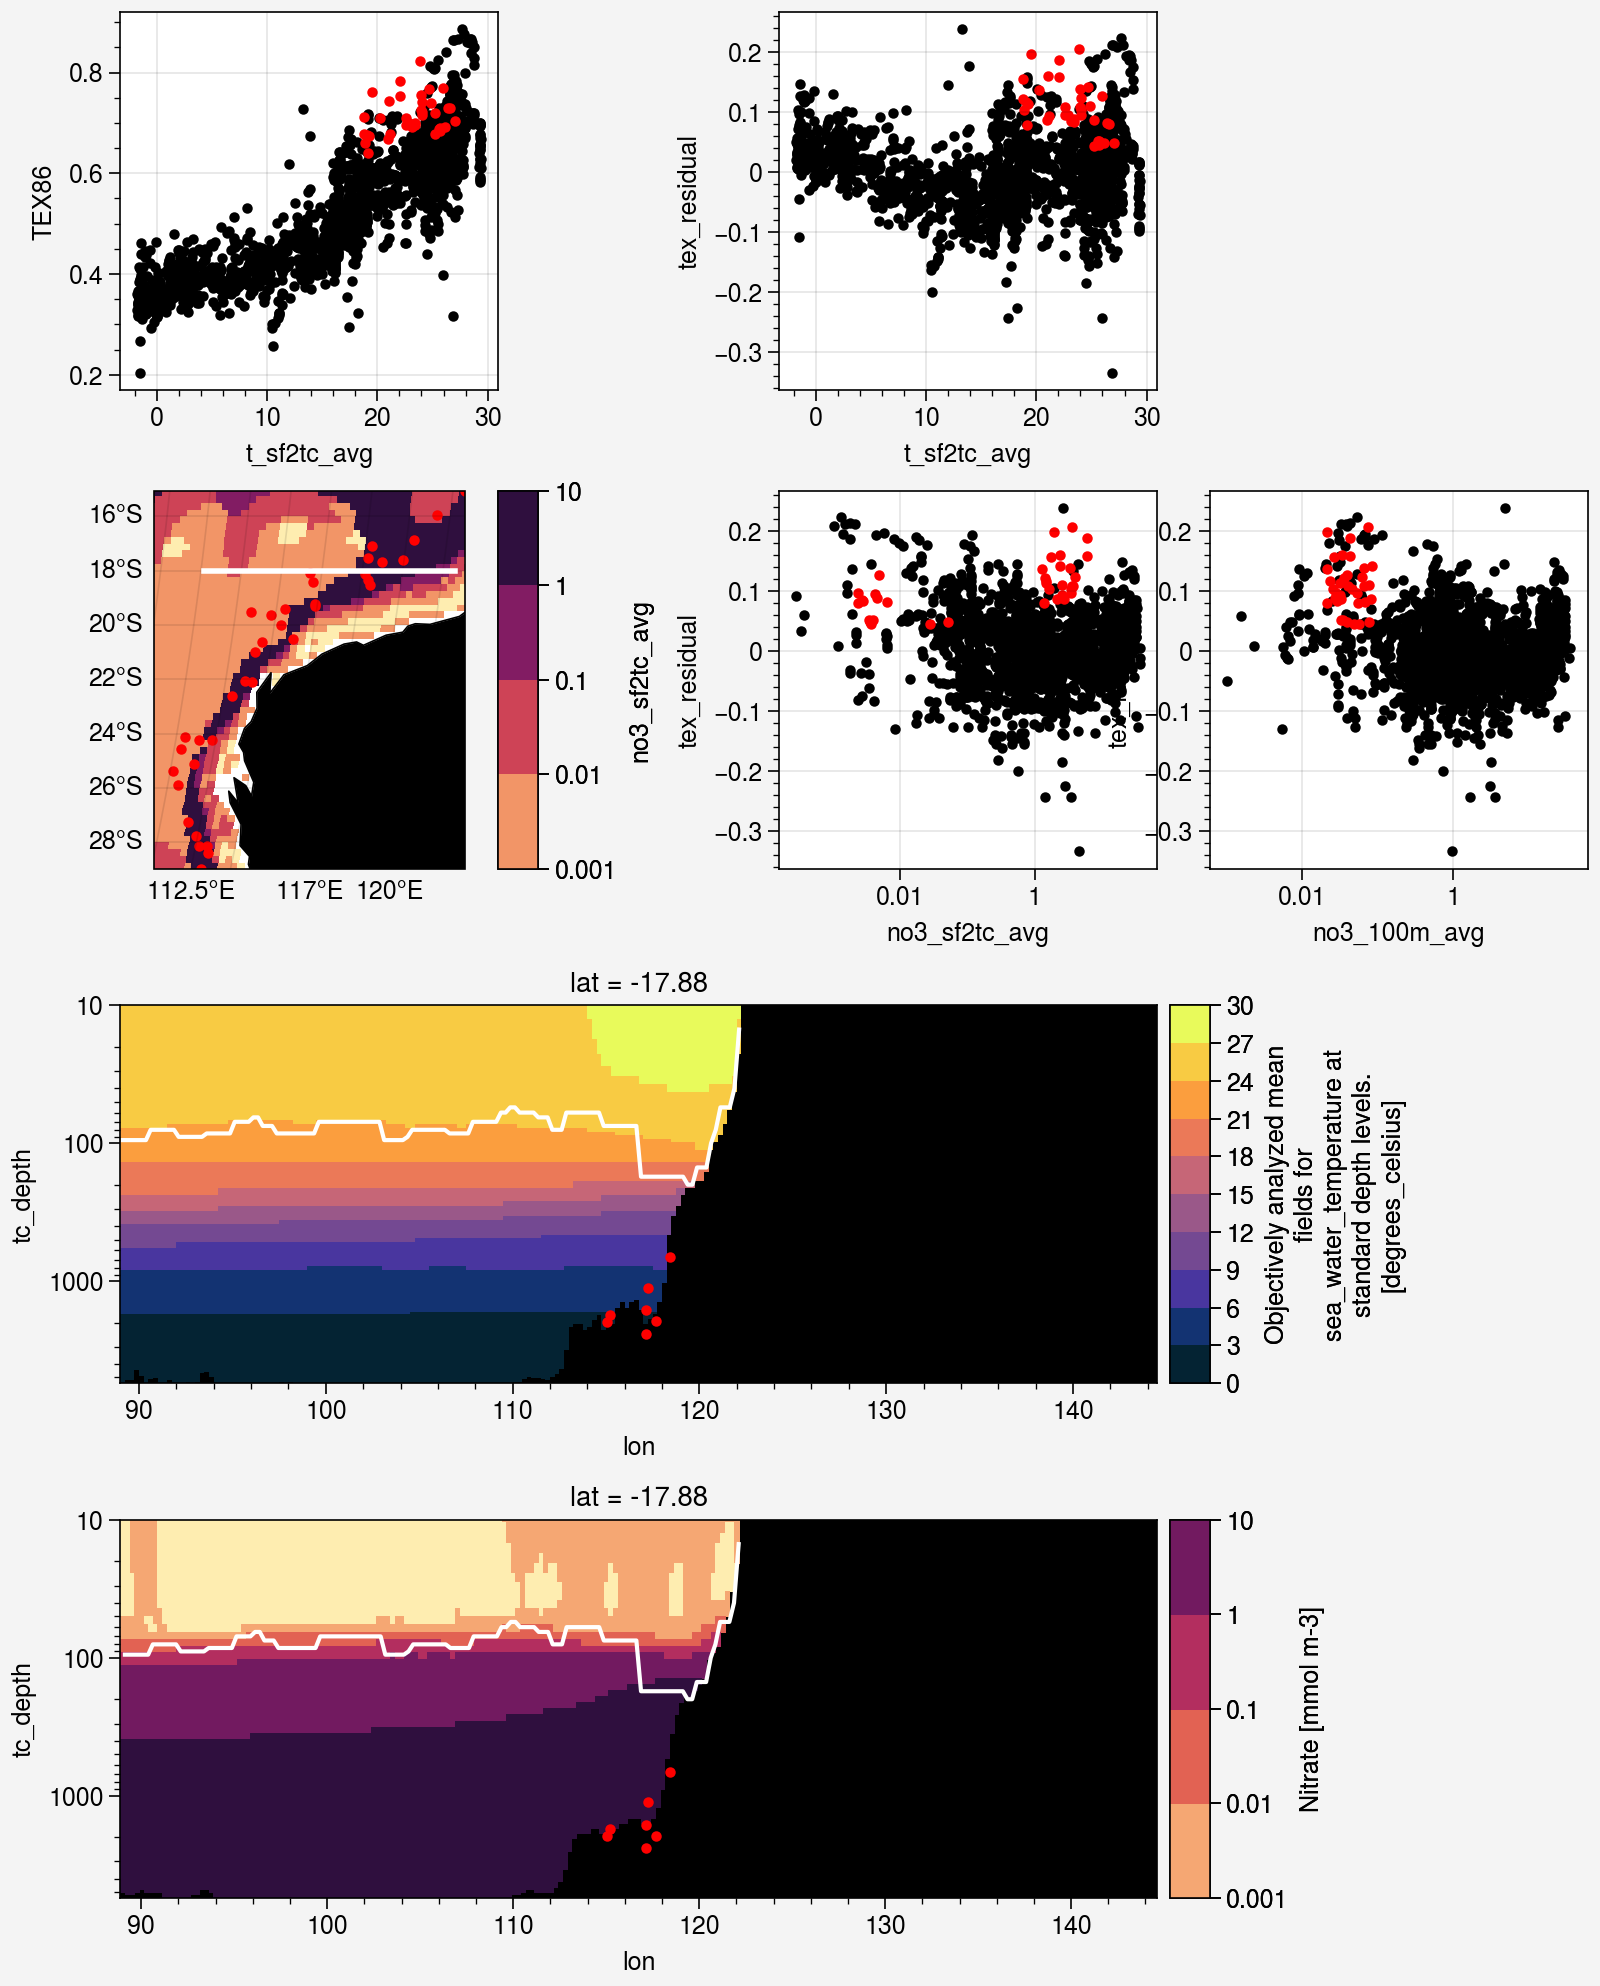

In [ ]:
array = [
    [1,2,0],
    [3,4,7],
    [5,5,0],
    [6,6,0],
]

fig, axs = plot.subplots(array,width=8,
                         proj=(None,None,'eck3',None,None),share=0)

plot_data = coretop_df
ax = axs[0]
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['TEX86']
ax.scatter(plot_x, plot_y, color='k', s=10, label='Coretops')

plot_data = trang_coretop_df
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['TEX86']
ax.scatter(plot_x, plot_y, color='r', s=10, label='Transect coretops')

ax = axs[1]
plot_data = coretop_df
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['tex_residual']
ax.scatter(plot_x, plot_y, color='k', s=10, label='Coretops')

plot_data = trang_coretop_df
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['tex_residual']
ax.scatter(plot_x, plot_y, color='r', s=10, label='Transect coretops')

ax = axs[2]
maxLat = trang_coretop_df['Latitude'].max()
minLat = trang_coretop_df['Latitude'].min()
maxLon = trang_coretop_df['Longitude'].max()
minLon = trang_coretop_df['Longitude'].min()
ax.format(
    lonlim=(minLon, maxLon), latlim=(minLat, maxLat),
    land=True, labels=True, coast=True
)

ds['no3_sf2tc_avg'].sel(lat=slice(minLat,maxLat),
                        lon=slice(minLon*0.8,maxLon*1.2)).plot(ax=ax, 
                                                               robust=True,
                                                       levels=[1e-3,1e-2,1e-1,1e0,1e1,],
                                                       cmap='matter', add_colorbar=True)
### add latitude trasect line
sel_lat = -18
ax.plot([minLon,maxLon],[sel_lat,sel_lat],color='w',lw=2)                       
                        
plot_data = trang_coretop_df
plot_lat = plot_data['Latitude']
plot_lon = plot_data['Longitude']
ax.scatter(plot_lon, plot_lat, color='r', s=10, label='Trang coretops')

ax = axs[3]
plot_data = coretop_df
plot_x = plot_data['no3_sf2tc_avg']
plot_y = plot_data['tex_residual']
ax.scatter(plot_x, plot_y, color='k', s=10, label='Coretops')

plot_data = trang_coretop_df
plot_x = plot_data['no3_sf2tc_avg']
plot_y = plot_data['tex_residual']
ax.scatter(plot_x, plot_y, color='r', s=10, label='Transect coretops')

ax.format(
    xscale='log'
)

ax = axs[6]
plot_data = coretop_df
plot_x = plot_data['no3_100m_avg']
plot_y = plot_data['tex_residual']
ax.scatter(plot_x, plot_y, color='k', s=10, label='Coretops')

plot_data = trang_coretop_df
plot_x = plot_data['no3_100m_avg']
plot_y = plot_data['tex_residual']
ax.scatter(plot_x, plot_y, color='r', s=10, label='Transect coretops')

ax.format(
    xscale='log'
)


ax = axs[4]

T_da.sel(lon=slice(minLon*0.8,maxLon*1.2)).sel(lat=sel_lat, method='nearest').plot(ax=ax,
                                                                                   robust=True,
                                                                                   levels=10,
                                                                                   cmap='thermal')
plot_data = trang_coretop_df[trang_coretop_df['Latitude'].between(sel_lat-0.5,sel_lat+0.5)]
plot_lon = plot_data['Longitude']
plot_depth = plot_data['WaterDepth']
ax.scatter(plot_lon, plot_depth*np.ones_like(plot_lon), color='r', s=10, label='Trang coretops')
ax.format(
    ylim=(5500,10),
    yscale='log',
    facecolor='k'
)

ds['tc_depth'].sel(lon=slice(minLon*0.8,maxLon*1.2)).sel(lat=sel_lat, method='nearest').plot(ax=ax,c='w')

ax = axs[5]
nitrate_CMEMS_da.sel(lon=slice(minLon*0.8,maxLon*1.2)).sel(lat=sel_lat, method='nearest').plot(ax=ax,robust=True,
                                                                                   levels=[1e-3,1e-2,1e-1,1e0,1e1,],
                                                                                   cmap='matter')
ds['tc_depth'].sel(lon=slice(minLon*0.8,maxLon*1.2)).sel(lat=sel_lat, method='nearest').plot(ax=ax,c='w')
plot_data = trang_coretop_df[trang_coretop_df['Latitude'].between(sel_lat-0.5,sel_lat+0.5)]
plot_lon = plot_data['Longitude']
plot_depth = plot_data['WaterDepth']
ax.scatter(plot_lon, plot_depth*np.ones_like(plot_lon), color='r', s=10, label='Trang coretops')
ax.format(
    ylim=(5500,10),
    yscale='log',
    facecolor='k'
)

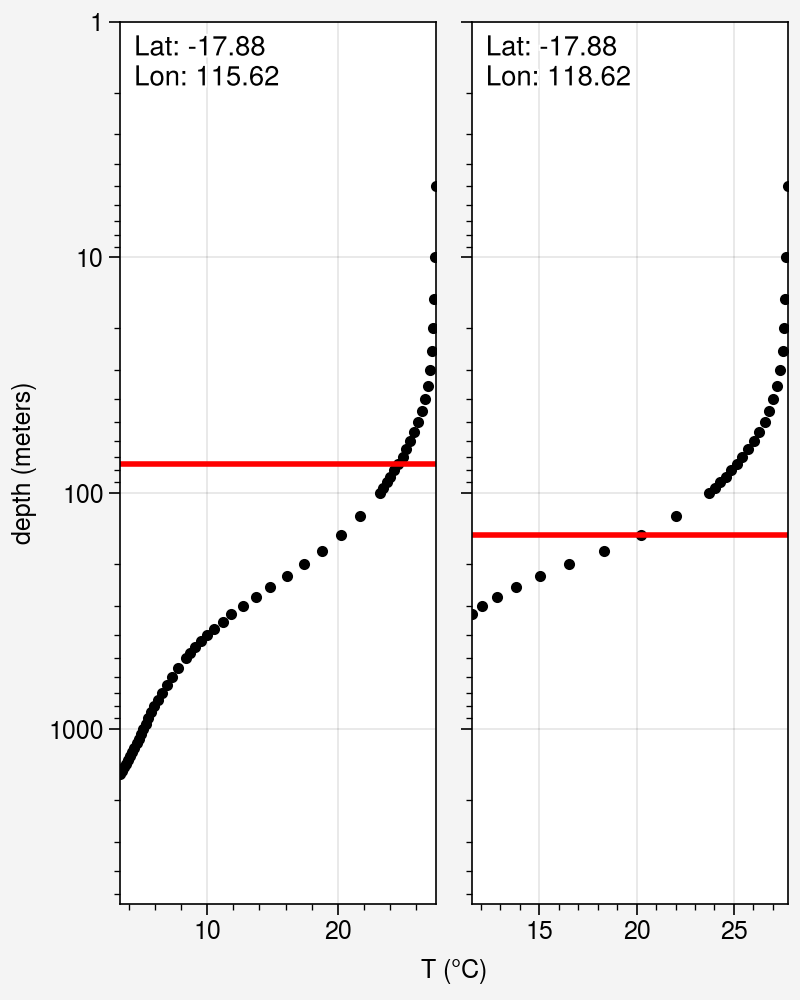

In [ ]:
fig, axs = plot.subplots(figsize=(4,5),ncols=2)

ax = axs[0]
sel_lat = -18
sel_lon =115.5
temp_data = T_da.sel(lat=sel_lat, lon=sel_lon, method='nearest')
match_lat = T_da.sel(lat=sel_lat, method='nearest').lat
match_lon = T_da.sel(lon=sel_lon, method='nearest').lon
depths = T_da.depth
plot_x = temp_data
plot_y = depths
ax.plot(plot_x, plot_y,'.', color='k', lw=2)

## calculate thermocline depth based on the maximum gradient
grad = np.gradient(temp_data)/np.gradient(depths)
grad_min = np.nanmin(grad)
grad_min_idx = np.where(grad == grad_min)[0][0]
thermocline_depth = depths[grad_min_idx]
ax.axhline(thermocline_depth, color='r', lw=2)


ax.format(
    ultitle='Lat: {:.2f}\nLon: {:.2f}'.format(match_lat.values, match_lon.values),
    xreverse=False,
    ylim=(1500,1),
    yscale='log',
    xlabel='T ($\degree$C)',
)

ax = axs[1]
sel_lat = -18
sel_lon =118.5
temp_data = T_da.sel(lat=sel_lat, lon=sel_lon, method='nearest')
match_lat = T_da.sel(lat=sel_lat, method='nearest').lat
match_lon = T_da.sel(lon=sel_lon, method='nearest').lon
depths = T_da.depth
plot_x = temp_data
plot_y = depths
ax.plot(plot_x, plot_y,'.', color='k', lw=2)

## calculate thermocline depth based on the maximum gradient
grad = np.gradient(temp_data)/np.gradient(depths)
grad_min = np.nanmin(grad)
grad_min_idx = np.where(grad == grad_min)[0][0]
thermocline_depth = depths[grad_min_idx]
ax.axhline(thermocline_depth, color='r', lw=2)


ax.format(
    ultitle='Lat: {:.2f}\nLon: {:.2f}'.format(match_lat.values, match_lon.values),
    xreverse=False,
    ylim=(5500,1),
    yscale='log',
    xlabel='T ($\degree$C)',
)